# MongoDB Charts  
**CC3089 – Base de Datos 2**  
Universidad del Valle de Guatemala  
Sección 10  

---

Diego López – 23242  
Diego Rosales – 23258  
Jonathan Zacarias – 231104  

---

Guatemala, 19 de febrero de 2026

## Instancia de MongoDB Atlas

Como grupo, creamos y configuramos nuestra propia instancia de MongoDB Atlas, la cual utilizaremos para almacenar los datos cargados desde el archivo .csv y para conectarla posteriormente con MongoDB Charts.

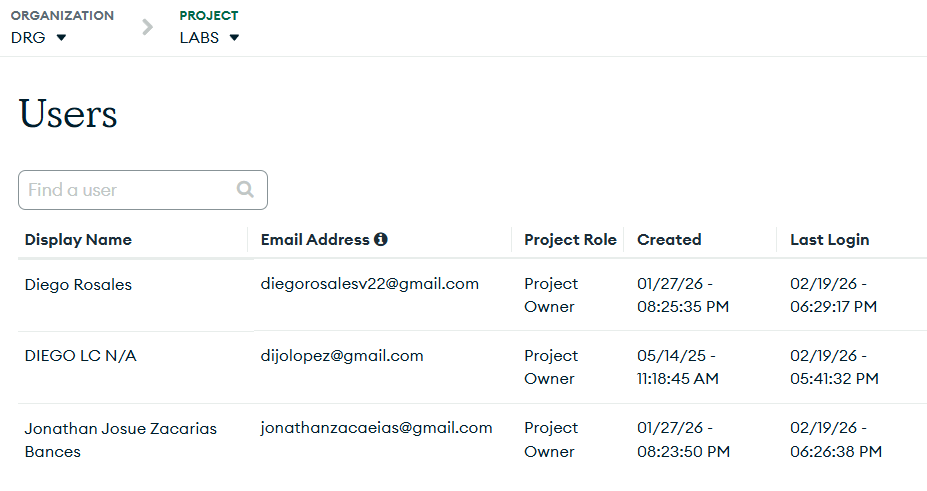

## Lectura del archivo CSV

En esta sección se realiza la lectura del archivo `.csv` que contiene los datos crudos, utilizando la librería `pandas` para su posterior procesamiento e inserción en MongoDB Atlas.

In [10]:
import pandas as pd

file_path = "data/Gaming and Mental Health.csv" 

df = pd.read_csv(file_path)

df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


## Preparación y carga a MongoDB Atlas

En esta sección se realiza:
1. Perfilado de columnas y calidad de datos.
2. Estandarización de nombres de columnas para MongoDB.
3. Conversión automática de tipos (numéricos/fechas cuando aplica).
4. Inserción en MongoDB Atlas para construir visualizaciones en MongoDB Charts.

In [11]:
import os
import re
from datetime import datetime

import numpy as np
from pymongo import MongoClient

print(f"Shape: {df.shape}")
print("\nColumnas originales:")
print(df.columns.tolist())

print("\nTipos originales:")
print(df.dtypes)

print("\nNulos por columna:")
print(df.isna().sum().sort_values(ascending=False))


original_columns = df.columns.tolist()

normalized_columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)


seen = {}
resolved_columns = []
for column in normalized_columns:
    if column not in seen:
        seen[column] = 0
        resolved_columns.append(column)
    else:
        seen[column] += 1
        resolved_columns.append(f"{column}_{seen[column]}")

df.columns = resolved_columns

column_mapping = dict(zip(original_columns, df.columns))
print("\nMapeo de columnas (original -> normalizada):")
for old, new in column_mapping.items():
    print(f"- {old} -> {new}")

Shape: (1000, 27)

Columnas originales:
['record_id', 'age', 'gender', 'daily_gaming_hours', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa', 'work_productivity_score', 'mood_state', 'mood_swing_frequency', 'withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems', 'eye_strain', 'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score', 'face_to_face_social_hours_weekly', 'monthly_game_spending_usd', 'years_gaming', 'gaming_addiction_risk_level']

Tipos originales:
record_id                               str
age                                   int64
gender                                  str
daily_gaming_hours                  float64
game_genre                              str
primary_game                            str
gaming_platform                         str
sleep_hours                         float64
sleep_quality         

In [12]:
# Conversión automática de tipos para mejorar Charts

df_clean = df.copy()


for col in df_clean.select_dtypes(include=["object"]).columns:
    df_clean[col] = df_clean[col].apply(lambda value: value.strip() if isinstance(value, str) else value)
    df_clean[col] = df_clean[col].replace({"": None, "na": None, "n/a": None, "null": None, "none": None})


for col in df_clean.columns:
    if df_clean[col].dtype == "object":
        series = df_clean[col].dropna().astype(str)
        if len(series) == 0:
            continue

        numeric_candidate = pd.to_numeric(
            series.str.replace(r"[^0-9.\-]", "", regex=True),
            errors="coerce"
        )
        conversion_ratio = numeric_candidate.notna().mean()

        if conversion_ratio >= 0.8:
            full_numeric = pd.to_numeric(
                df_clean[col].astype(str).str.replace(r"[^0-9.\-]", "", regex=True),
                errors="coerce"
            )
            df_clean[col] = full_numeric


for col in df_clean.columns:
    if df_clean[col].dtype == "object":
        series = df_clean[col].dropna().astype(str)
        if len(series) == 0:
            continue

        date_candidate = pd.to_datetime(series, errors="coerce", utc=True)
        conversion_ratio = date_candidate.notna().mean()

        if conversion_ratio >= 0.8:
            df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce", utc=True)


records_df = df_clean.replace({np.nan: None})

print("\nTipos finales (después de conversión automática):")
print(records_df.dtypes)


Tipos finales (después de conversión automática):
record_id                              str
age                                  int64
gender                                 str
daily_gaming_hours                  object
game_genre                             str
primary_game                           str
gaming_platform                        str
sleep_hours                         object
sleep_quality                          str
sleep_disruption_frequency             str
academic_work_performance              str
grades_gpa                          object
work_productivity_score             object
mood_state                             str
mood_swing_frequency                   str
withdrawal_symptoms                   bool
loss_of_other_interests               bool
continued_despite_problems            bool
eye_strain                            bool
back_neck_pain                        bool
weight_change_kg                    object
exercise_hours_weekly               object
soc

C:\Users\dijol\AppData\Local\Temp\ipykernel_26196\1584352643.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include=["object"]).columns:


In [14]:
from dotenv import load_dotenv

load_dotenv(".env")

MONGO_URI = os.getenv("MONGODB_ATLAS_URI", "")
DB_NAME = "bd_lab4"
ANALYTICS_COLLECTION = "gaming_mental_health_analytics"

if not MONGO_URI:
    raise ValueError("No se encontró MONGODB_ATLAS_URI en .env")

client = MongoClient(MONGO_URI)
db = client[DB_NAME]

analytics_collection = db[ANALYTICS_COLLECTION]


analytics_collection.drop()
analytics_records = records_df.to_dict(orient="records")
if analytics_records:
    analytics_collection.insert_many(analytics_records)

print("Carga finalizada.")
print(f"- ANALYTICS docs: {analytics_collection.count_documents({})}")

Carga finalizada.
- ANALYTICS docs: 1000


In [ ]:


sample_docs = list(analytics_collection.find({}, {"_id": 0}).limit(3))
print("\nEjemplo de documentos ANALYTICS:")
for doc in sample_docs:
    print(doc)